# Shooter Performance Feature Engineering - VR Shooting Simulation

This notebook turns raw VR shooting logs (controller/headset/eye-tracking
frames plus drill/repetition/shot events) into five interpretable
shot-quality features, one per performance domain, plus a derived sixth
(decision quality). Two more metrics were built and validated along the way
but didn't get promoted to the main set; Section 2 covers why.

It then presents those features twice: as a plain-language dashboard for the
shooter, and as a PM-facing writeup of why each one was chosen and how it
could map to product feedback. See `CLAUDE.md` for the data dictionary and
`README.md` for how to run this.

**Cohort:** 7 users, each running the same `TargetAcquisition` scenario
(about 31 shots and 24 repetitions per session, roughly 6 minutes). An 8th
file (user 243, `WarmUp` scenario, 350 shots) is a different drill and is
left out of the cross-user comparisons - see Section 5. It's used instead in
Section 4 for a question the 7-user cohort can't answer: how do these
features move across many repetitions for one person?

## 0. Data loading & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shooter.parse import parse_file
from shooter.build_features import build, DATA_DIR, EXCLUDED_SCENARIOS
from shooter.features import MAIN_FEATURES, SUPPLEMENTARY_FEATURES
from shooter.dashboard import skill_scores, plot_scorecard, plot_good_vs_bad, plot_hit_map, plot_feature_vs_score
from shooter.reporting import drift_summary, split_times

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)

**Filenames** follow `Timestamp_UserId_SessionId_ScenarioID.event.json`.
Each file is NDJSON (one JSON object per line), so we read it by streaming
`json.loads` per line instead of `pandas.read_json` - files run 20-75MB, and
loading the whole thing into memory at once buys nothing for a
line-oriented format.

First, a look at one file's raw structure: event-type volumes and frame
rate.

In [2]:
sample_path = sorted(DATA_DIR.glob("*.event.json"))[3]  # the 238 file used to explore the data
frames, shots_sample = parse_file(sample_path)
print(sample_path.name)
for t, df in sorted(frames.items(), key=lambda kv: -len(kv[1])):
    print(f"{len(df):>7}  {t}")

20260601072221_238_2566_11639.event.json
  31735  controller
  31735  headset
  31735  eye_data
    144  drill_state_change
     96  shooting_requirement_change
     96  target_state_change
     48  buzzer
     31  shot_start
     31  shot_resolved
     24  repetition_start
     24  repetition_end
      1  session_metadata
      1  scenario_start
      1  location_metadata
      1  scenario_end


median frame gap: 11.0 ms  (~91 Hz)


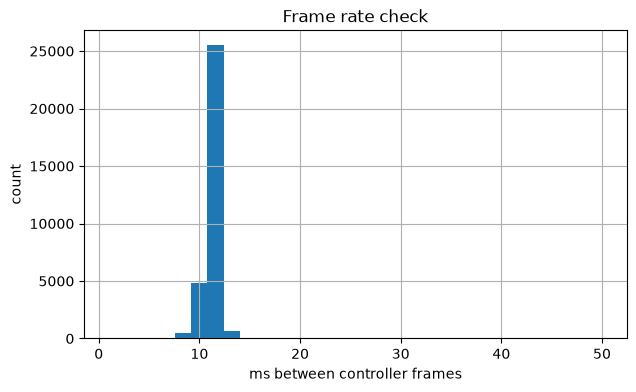

In [3]:
# Frame rate: gaps between consecutive controller frames (ms). Frame data is
# logged at a steady rate -- this just confirms it and sets expectations for
# window sizes used later (TRIGGER_WINDOW_MS, GAZE_WINDOW_MS in features.py).
gaps = frames["controller"]["Time"].diff().dropna()
print(f"median frame gap: {gaps.median():.1f} ms  (~{1000/gaps.median():.0f} Hz)")
gaps.clip(upper=50).hist(bins=30)
plt.xlabel("ms between controller frames"); plt.ylabel("count"); plt.title("Frame rate check");

**Timestamp note:** `Time` is an integer millisecond epoch, but in this
sample it decodes to a date around 2026 - almost certainly a synthetic or
shifted clock rather than a real recording date. We only ever use
*differences* between `Time` values (reaction time, window slicing), never
the absolute wall-clock value, so this has no effect on any feature.

**Event ordering:** events of different `Type` are interleaved in the file
and aren't guaranteed to be causally ordered even after sorting by `Time`.
We found a concrete case of this: a `shooting_requirement_change` "clear"
can land at the exact same millisecond as the `shot_start` that triggered
it, and a plain stable sort leaves "clear" first - making it look like the
requirement was already gone before the shot that satisfied it.
`shooter/parse.py` breaks ties at equal timestamps by processing
`shot_start` before `shooting_requirement_change`. After that fix, our
recomputed valid-hit flag (`object_id` matched against whichever
requirement was live at shot time) agrees with the engine's own
`object_type` label on **100% of shots** across all 8 files - good evidence
that the event model (drill -> repetition -> buzzer -> requirement -> shot)
was reconstructed correctly.

In [4]:
frames, shots_sample = parse_file(sample_path)  # rebuilt with the tie-break fix already in parse.py
mismatch = (shots_sample["valid_hit_recomputed"] != (shots_sample["object_type"] == "valid")).mean()
print(f"disagreement between recomputed valid-hit and engine object_type: {mismatch:.0%}")

disagreement between recomputed valid-hit and engine object_type: 0%


**Eye-tracking data quality:** `valid.<eye>` / `open.<eye>` record per-frame
tracking confidence. One user (243) has consistently lower left-eye
validity (about 75-78%) than right-eye (about 90-96%) across both of their
sessions, despite `session_metadata` listing `dominant_eye = "Left"` - that
pattern looks like a per-user calibration or sensor issue rather than
ordinary blinking. `add_gaze_and_pupil` in `shooter/features.py` handles
this by preferring the dominant eye but falling back to the other eye, per
shot, whenever the dominant eye doesn't clear a minimum valid-frame count in
its window, instead of just returning NaN for that user's gaze features.

In [5]:
rows = []
for path in sorted(DATA_DIR.glob("*.event.json")):
    f, _ = parse_file(path)
    eye = f["eye_data"]
    uid = f["session_metadata"]["user_id"].iloc[0]
    dom = f["session_metadata"]["dominant_eye"].iloc[0]
    rows.append({"user_id": uid, "dominant_eye": dom,
                 "left_valid_rate": eye["valid.left"].mean(), "right_valid_rate": eye["valid.right"].mean()})
pd.DataFrame(rows).round(2)

,user_id,dominant_eye,left_valid_rate,right_valid_rate
0,234,Right,0.99,0.98
1,235,Right,0.95,0.95
2,237,Right,0.80,0.89
3,238,Left,0.93,0.89
4,240,Left,0.94,0.93
5,244,Left,0.98,0.82
6,243,Left,0.78,0.90
7,243,Left,0.72,0.96


### 0.1 Data deep-dive: composition, scale, and what made it tricky

A closer look at all eight files, not just the one sampled above - what they
actually contain, and the rough edges that showed up while turning them into
a clean shot table.

In [6]:
rows = []
for path in sorted(DATA_DIR.glob("*.event.json")):
    f, s = parse_file(path)
    rows.append({
        "file": path.name, "size_mb": round(path.stat().st_size / 1e6, 1),
        "scenario_id": s["scenario_id"].iloc[0] if len(s) else None,
        "controller_frames": len(f.get("controller", [])),
        "eye_frames": len(f.get("eye_data", [])),
        "n_drills": s["drill_id"].nunique() if len(s) else 0,
        "n_reps": s["rep_idx"].nunique() if len(s) else 0,
        "n_shots": len(s),
    })
pd.DataFrame(rows).set_index("file")

,size_mb,scenario_id,controller_frames,eye_frames,n_drills,n_reps,n_shots
file,,,,,,,
20260601071951_234_2563_11634.event.json,21.1,11634,23358,23358,24,24,31
20260601072107_235_2562_11640.event.json,23.8,11640,26379,26379,24,24,31
20260601072157_237_2564_11635.event.json,31.6,11635,35475,35475,24,24,31
20260601072221_238_2566_11639.event.json,28.4,11639,31735,31735,24,24,31
20260601073738_240_2569_11642.event.json,22.4,11642,24918,24918,24,24,31
20260601073843_244_2572_11641.event.json,24.5,11641,27361,27361,24,24,31
20260601073914_243_2570_11646.event.json,26.1,11646,29355,29355,23,23,30
20260601113226_243_2531_11601.event.json,75.8,11601,84850,84850,72,72,350


Frame rate is the same across all eight files (the ~90 Hz established
above) - size and event counts scale with session length and drill count,
not a different recording rig. The cross-user cohort's seven files are all
the same shape: 21-32 MB, 24 drills, 24 repetitions, 30-31 shots, one drill
repeated with a different target each time.

The eighth file (`WarmUp`, user 243, scenario `11601`) is the outlier on
every axis: 76 MB, 72 drills, 72 repetitions, 350 shots, in a 15-minute
session - about 3x the data of any cohort file. It isn't just a different
scenario label; it packs **11 distinct drill types** (`TargetAcquisition`,
`SplitShooting`, `NeutralizeThreat`, `TargetTransition`, `ThrottleControl`,
`FriendVsFoe`, `TargetIdentification`, `SuppressiveFire`, `TakeCover`,
`JohnWick`, plus warm-up variants), each repeated several times in a row.
That structure is exactly why it's excluded from the cross-user comparison
above (different task) and exactly what makes it useful for a different
question in Section 4: how features move across many repetitions for one
person, which the 24-repetition-once-each cohort files can't show.

Per-frame types (`controller`, `headset`, `eye_data`) account for nearly all
of the row volume - tens of thousands of rows per file. The dozen event
types that carry the drill/repetition/shot structure are comparatively rare
(single digits to low hundreds per file). That lopsided mix is the "dense
time-series + sparse event log" shape the brief describes, and it's the
reason `parse.py` streams every line into one pass rather than filtering by
type at read time - there's no volume saved by special-casing the rare types.

**Challenges encountered**, beyond the event-ordering tie-break and
eye-tracking calibration issue already covered above:

- **`repetition_start.id` is always `0`.** Every repetition in every file
  logs the same id, so repetitions can't be identified by id at all -
  `parse.py` tracks them by arrival order (`rep_idx`) instead. The same is
  true of `shot_start`/`shot_resolved` ids, which reset to `0` at the start
  of each repetition and only disambiguate shots *within* the current
  repetition, not across the whole file.
- **Not every `shot_resolved.object_id` is a `LINE_.../.../.../...` target.**
  A handful of shots in the cohort files resolve against static scene props
  instead (`PrpSandBagsWallA1_LOD2.11`, `WallBack_Collider` - cover geometry,
  not scoring targets). The path matcher in `parse.py` treats anything that
  doesn't split into exactly four segments as a non-match rather than
  raising, so these correctly fail to satisfy any shooting requirement
  without crashing the pipeline - a reminder that `object_id` is "whatever
  the raycast hit," not "always a scoreable target."
- **The `WarmUp` file uses a second target-naming scheme.** Several of its
  drills (its `FriendVsFoe` drill, in particular) resolve shots against
  `B_LINE_<row>/<col>/TARGET/<zone>` paths instead of `LINE_.../BODY/...` -
  a distinct target class, not a typo, since the matching `add` requirements
  use the same `B_LINE_` prefix. The matcher never hardcodes `"LINE_"`, only
  segment-by-segment equality, so it handles this correctly without any
  special-casing: recomputed valid-hit still agrees with the engine's
  `object_type` on 99.7% of this file's 350 shots (vs. 100% for the cohort).
- **A duplicate repetition id inside one drill.** In the `WarmUp` file's
  `SuppressiveFire` drill, repetition id `09.01` appears twice
  (`...09.01`, `...09.02`, `...09.01` again, `...09.03`) instead of a clean
  `.01`-`.04` run - read as a retried/restarted repetition rather than a
  parser bug. `parse.py`'s arrival-order `rep_idx` isn't affected either way,
  since it never relies on the id being unique, but it's a sign drill ids
  aren't a fully reliable key on their own.
- **`eye_data.convergence.distance` is flat at `100.0`** across every frame
  sampled - flagged again here because it means we can't tell, from this
  sample alone, whether it's unimplemented for this build or just degenerate
  for these scenarios.

## Building the per-shot feature table

The core join (`shooter/parse.py: build_shot_table`) replays every event in
`Time` order, keeping drill, repetition, buzzer, and "live" shooting
requirements as running state, and emits one row per `shot_resolved` joined
to its matching `shot_start`, repetition, and active requirement.
`shooter/features.py` then adds the feature columns on top of that table.

In [7]:
shots = build(DATA_DIR)
print(f"{len(shots)} shots from {shots['user_id'].nunique()} users "
      f"(scenario {sorted(shots['scenario_id'].unique())}; excluded scenarios: {EXCLUDED_SCENARIOS})")
shots[["user_id", "rep_idx", "reaction_time_s", "radial_error_m", "trigger_press_duration_s",
       "trigger_smoothness", "gaze_target_angle_deg", "quiet_eye_duration_s",
       "valid_hit_recomputed", "score"]].head()

216 shots from 7 users (scenario [np.int64(11634), np.int64(11635), np.int64(11639), np.int64(11640), np.int64(11641), np.int64(11642), np.int64(11646)]; excluded scenarios: {11601})


,user_id,rep_idx,reaction_time_s,radial_error_m,trigger_press_duration_s,trigger_smoothness,gaze_target_angle_deg,quiet_eye_duration_s,valid_hit_recomputed,score
0,234,0,2.534,0.077496,0.623,0.013938,1.452045,1.000,True,5.0
1,234,1,2.379,0.021984,0.790,0.011698,1.272987,1.000,True,5.0
2,234,2,2.281,0.075626,0.489,0.013697,1.191945,0.834,True,2.0
3,234,3,1.945,0.125847,0.644,0.012849,1.203318,1.000,True,2.0
4,234,4,2.675,0.052760,0.044,0.027782,1.377309,1.000,True,4.0


## 1. Shooter Dashboard

A plain-language summary for one shooter (user 238, chosen because their
profile mixes clear strengths and clear weaknesses, which makes for a more
useful example than someone who's simply good or bad across the board).
Scores are **0-100 percentiles against the other 6 users in this cohort**:
100 is best in the group, 50 is the middle. With only 7 users this is a
coarse ranking, not a calibrated population norm (see Section 5).

In [8]:
DEMO_USER = 238
raw, scores = skill_scores(shots)
raw.round(2)

,accuracy,speed,stability,focus,quiet_eye,decision
user_id,,,,,,
234,0.19,2.18,0.03,1.78,0.80,0.74
235,0.17,2.36,0.02,1.65,0.86,0.84
237,0.40,2.11,0.05,5.24,0.47,0.71
238,0.36,2.00,0.08,5.75,0.47,0.71
240,0.39,2.12,0.06,9.99,0.64,0.71
243,0.34,2.40,0.06,7.55,0.06,0.60
244,0.22,2.50,0.04,5.36,0.45,0.84


In [9]:
scores.round(0)

,accuracy,speed,stability,focus,quiet_eye,decision
user_id,,,,,,
234,71.0,43.0,71.0,71.0,86.0,71.0
235,86.0,29.0,86.0,86.0,100.0,93.0
237,0.0,71.0,43.0,57.0,43.0,43.0
238,29.0,86.0,0.0,29.0,57.0,43.0
240,14.0,57.0,14.0,0.0,71.0,43.0
243,43.0,14.0,29.0,14.0,14.0,14.0
244,57.0,0.0,57.0,43.0,29.0,93.0


**Shot-level results** for user 238 - one row per shot, in firing order.

In [10]:
shots[shots["user_id"] == DEMO_USER][[
    "rep_idx", "score", "radial_error_m", "reaction_time_s",
    "gaze_target_angle_deg", "quiet_eye_duration_s", "valid_hit_recomputed",
]].reset_index(drop=True)

,rep_idx,score,radial_error_m,reaction_time_s,gaze_target_angle_deg,quiet_eye_duration_s,valid_hit_recomputed
0,0,2.0,0.099351,3.690,0.524453,1.000,True
1,1,0.0,0.796819,2.424,6.338451,0.000,False
2,2,2.0,0.075684,2.145,1.022608,0.534,True
3,3,1.0,0.111538,1.758,1.032812,0.635,True
4,4,0.0,0.887324,1.900,6.762818,0.000,False
5,5,2.0,0.158669,2.000,1.454280,0.911,True
6,5,5.0,0.083757,2.346,1.387917,0.990,True
7,6,0.0,0.769709,1.967,7.659681,0.000,False
8,7,4.0,0.050973,1.845,1.941700,0.389,True
9,8,2.0,0.123306,1.645,2.795765,0.367,True


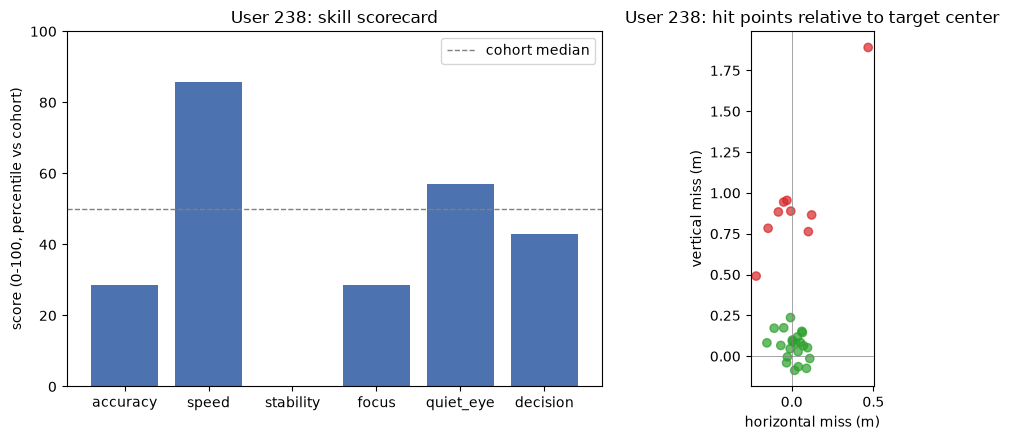

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_scorecard(scores, DEMO_USER, axes[0])
plot_hit_map(shots, DEMO_USER, axes[1])
fig.tight_layout()

**Plain-language feedback for user 238:** Your trigger finger is fast. You're
the quickest in the group to fire once you're allowed to shoot (top score on
speed). But that speed isn't paying off in steadiness: your trigger pull is
the jerkiest in the group (lowest stability score), and your eyes drift the
furthest from the target in the moment before you shoot (low focus score).
Accuracy and decision-quality both sit below the group median. **Bottom
line: you're shooting fast, but slow down on the final trigger squeeze and
keep your eyes locked on the target through the shot - right now speed is
costing you precision.**

## 2. Feature Explanation

The brief asks for 3-5 features, each from a different performance domain.
Building the pipeline, we ended up with seven candidate metrics across five
domains - more than one per domain in a couple of cases. Below is the **main
set of five**, one per domain, followed by a derived sixth (decision
quality) and then the two extra metrics we tested but didn't promote, along
with the reasoning for leaving each one out.

### Main features

| # | Feature | Domain | What it measures | Data source |
|---|---------|--------|-------------------|--------------|
| 1 | `reaction_time_s` | Timing / target acquisition | Seconds from `buzzer(start)` to `shot_start` | `buzzer`, `shot_start` |
| 2 | `radial_error_m` | Motor control / consistency | Distance from hit point to target center (x,y plane) | `shot_resolved.hit_local_location`/`center_local_location` |
| 3 | `trigger_smoothness` | Trigger control | Jaggedness of the final trigger pull before the shot | `controller.trigger_pull_value` |
| 4 | `gaze_target_angle_deg` | Eye behavior | Angle between gaze direction and target, averaged over the 500ms before the shot | `eye_data` |
| 5 | `quiet_eye_duration_s` | Cognitive | Duration of the final continuous on-target fixation right up to the trigger pull ("Quiet Eye") | `eye_data` |

#### 1. Reaction time (timing / target acquisition)
Time from the buzzer's "start" signal to the shot's trigger break - the most
direct measure we have of how quickly a shooter engages a presented target,
which is a tactical skill in its own right.

One assumption worth flagging: in multi-bullet repetitions, the second
bullet's "reaction time" includes whatever time was already spent on the
first bullet, so it reads as *time-to-fire-this-bullet-since-allowed* rather
than a clean reflex measure. We're calling that out rather than treating the
two cases as equivalent.

That confound has a clean fix: `split_time_s` (`shooter/reporting.py`) times
each bullet from the *previous* shot instead of the buzzer - the standard
practical-shooting follow-up-speed metric. It's undefined for the first
bullet of a repetition (nothing to measure from) but exact for everything
after; Section 3 shows how much this matters in practice.

For product, this maps directly to a "draw speed" or "time-to-first-shot"
metric for the shooter, and could back a pass/fail threshold in
time-limited scenarios.

#### 2. Precision and grouping (motor control / consistency)
Euclidean distance between the hit point and the target's center, in the
plane perpendicular to the line of fire (x = lateral, y = vertical; we drop
z, the depth into the target, since the engine already snaps it to the
target plane and it carries no aim-quality signal here).

This is about as basic a shot-quality measure as exists: even a "valid" hit
can land far from center, which matters for follow-up shot speed and
lethality in a realistic scenario. Looking at `radial_error_m` across
repeated shots at the same target row also gives a grouping/consistency
read, not just a single-shot number.

`radial_error_m` is a magnitude, though, so it can't tell apart a shooter
who's consistently off-center in one direction (a sight/grip/stance fix)
from one who scatters randomly around center (a consistency problem only
practice fixes) - both can produce the same average. `drift_summary`
(`shooter/reporting.py`) splits the same hits into a per-user **bias
vector** and **spread**, the breakdown that tells those two apart; see
Section 3 for what it finds in this cohort.

For product, this maps straight onto the "shot grouping" visualizations
shooters already expect from range training.

**A continuous score for the dashboard.** `radial_error_m` is already a
continuous accuracy score in meters, but raw meters is a poor number to show
a shooter directly, and the 7 shots that hit scenario props instead of a
target (no real center, `radial_error_m` undefined) would otherwise blow up
any average. `shot_quality_pct` rescales it to a bounded 0-100 number via
`100 * exp(-(radial_error_m / 0.116)^2)` (those 7 prop-hits get a hard 0),
where 0.116m was fit so the curve tracks the engine's own 0-5 `score` field.
We also tried normalizing by range first (angle instead of meters, so a 10cm
miss at 5m and at 10m would count the same) - it correlates *worse* with the
engine's score (Spearman 0.67 vs 0.83 for raw meters), because row-2 targets
(10m) score worse on average than row-1 (5m) despite being only 2x the
distance: the engine's scoring rings are a fixed physical size, not an
angular cone, so raw meters is the right unit to score on, not angle.
`shot_quality_pct` is a monotonic transform of `radial_error_m`, not a new
independent feature, so it doesn't get its own row in the table above - it
exists purely so non-technical readers and aggregate stats have a bounded,
intuitive number instead of raw meters.

#### 3. Trigger control
From the `trigger_pull_value` stream in the second before the shot, we take
`trigger_smoothness`: the standard deviation of frame-to-frame change during
the final press (lower = smoother). We're assuming the shot fires at or near
the local max of the pull within that window.

A jerky or "slapped" trigger pull is a well-known cause of low-and-left
misses in real shooting, and it's coachable independently of aim. A
below-peers smoothness score is a concrete, drillable cue ("work on
dry-fire trigger control") in a way that "shoot more accurately" isn't.

#### 4. Gaze and target alignment (eye behavior)
Angle between the dominant eye's `world_gaze_direction` and the vector to
the target center, averaged over the 500ms before the shot. This assumes
gaze and target-center coordinates share the same world frame, which we
checked by cross-referencing Section 0's hit-location coordinates against
`location_metadata.target_base`.

"Look where you want to shoot" is foundational marksmanship coaching, and a
large gaze-target angle right before the shot turns out to be a leading
indicator of a miss (Section 3). Of everything in this report, this is the
strongest candidate for a real-time in-VR cue ("eyes on target"), since it
precedes the shot rather than just describing it afterward.

#### 5. Quiet Eye duration (cognitive)
How long, continuously, gaze stayed within 3° of the target right up to the
trigger pull. We walk backward frame-by-frame from `shot_start` until gaze
leaves that tolerance or a frame gap signals a blink or tracking dropout.

This is the "Quiet Eye" measure from sports-vision research (Vickers, 1996):
the final fixation before a critical motor action, replicated specifically
in marksmanship and police-shooting studies (Causer, Bennett & Williams,
2010), where a longer pre-shot Quiet Eye duration predicts a higher hit
rate.

It's tempting to assume this just duplicates `gaze_target_angle_deg`, but
the two ask different questions. The angle feature averages over a fixed
500ms window, so a shooter whose gaze wanders onto target for most of that
window but breaks away right before firing still scores well on it. Quiet
Eye asks specifically how long gaze was locked on, uninterrupted, through
the moment of the shot - catching the failure mode the average can hide. A
`0.0s` value means gaze was already off-target at the shot and is a real
result, not missing data; `NaN` is reserved for windows with too few valid
gaze frames to judge.

The 3° tolerance and the trigger-pull instant as the Quiet Eye "offset" are
both literature-standard choices rather than something measured from this
dataset - a tighter or looser tolerance would shift the absolute durations
but not the cohort ranking (checked in Section 3). For product, this pairs
with the gaze-angle cue as a single, well-validated number that's easy to
coach directly - "hold your sight picture on target for at least half a
second before you break the shot" is a known drill in real-range Quiet Eye
training.

### Bonus: decision quality (cognitive, derived)
Beyond the five main features, we also compute the share of a user's shots
fired at a target that wasn't currently a "live" shooting requirement (for
example, hitting a no-score or off-target object while the intended target
was active). It's derived from the same event data as the others rather
than measured directly off a sensor, which is why we're treating it as a
bonus rather than one of the five.

It catches a failure mode none of the other features can see: "couldn't hit
the right target" (a motor/aim problem) is different from "shot the wrong
target" (a target-discrimination or impulse-control problem), and those
call for different coaching entirely. A shooter with a high non-valid rate
but otherwise good accuracy and reaction time probably needs discrimination
drills, not marksmanship ones.

### Supplementary features (tested, not in the main set)
Two more per-shot metrics came out of the same pipeline. Both are real,
validated columns in `features.csv` - they just didn't make the headline
five, for reasons specific to each:

- **`trigger_press_duration_s`** (time from a half-way pull threshold to the
  shot) sits in the same domain as `trigger_smoothness` and is correlated
  with it. Smoothness is the more diagnostic and more obviously coachable of
  the two, so it became the main trigger-control feature, and duration is
  kept as a supporting number rather than giving trigger control two
  headline slots.
- **`pupil_diameter_mm`** (mean pupil size in the pre-shot gaze window, as a
  cognitive-load/arousal proxy) is conceptually interesting, but unlike
  every main feature it never showed a clean separation between valid hits
  and misses or a correlation with the engine's `score` field (Section 3
  only runs that check on the main five). Without that evidence we're not
  comfortable presenting it as a validated shot-quality signal yet - flagged
  here as worth a second look once there's a clearer hypothesis for what
  pupil size should predict in this task. (`gaze_stability_deg`, the
  per-shot standard deviation of the gaze angle, is in the same boat: a
  reasonable idea, computed alongside the others, but not separately
  validated or promoted.)

## 3. Feature Validation / Supporting Analysis

The core trust check for every feature: does it actually separate good shots
from bad ones?

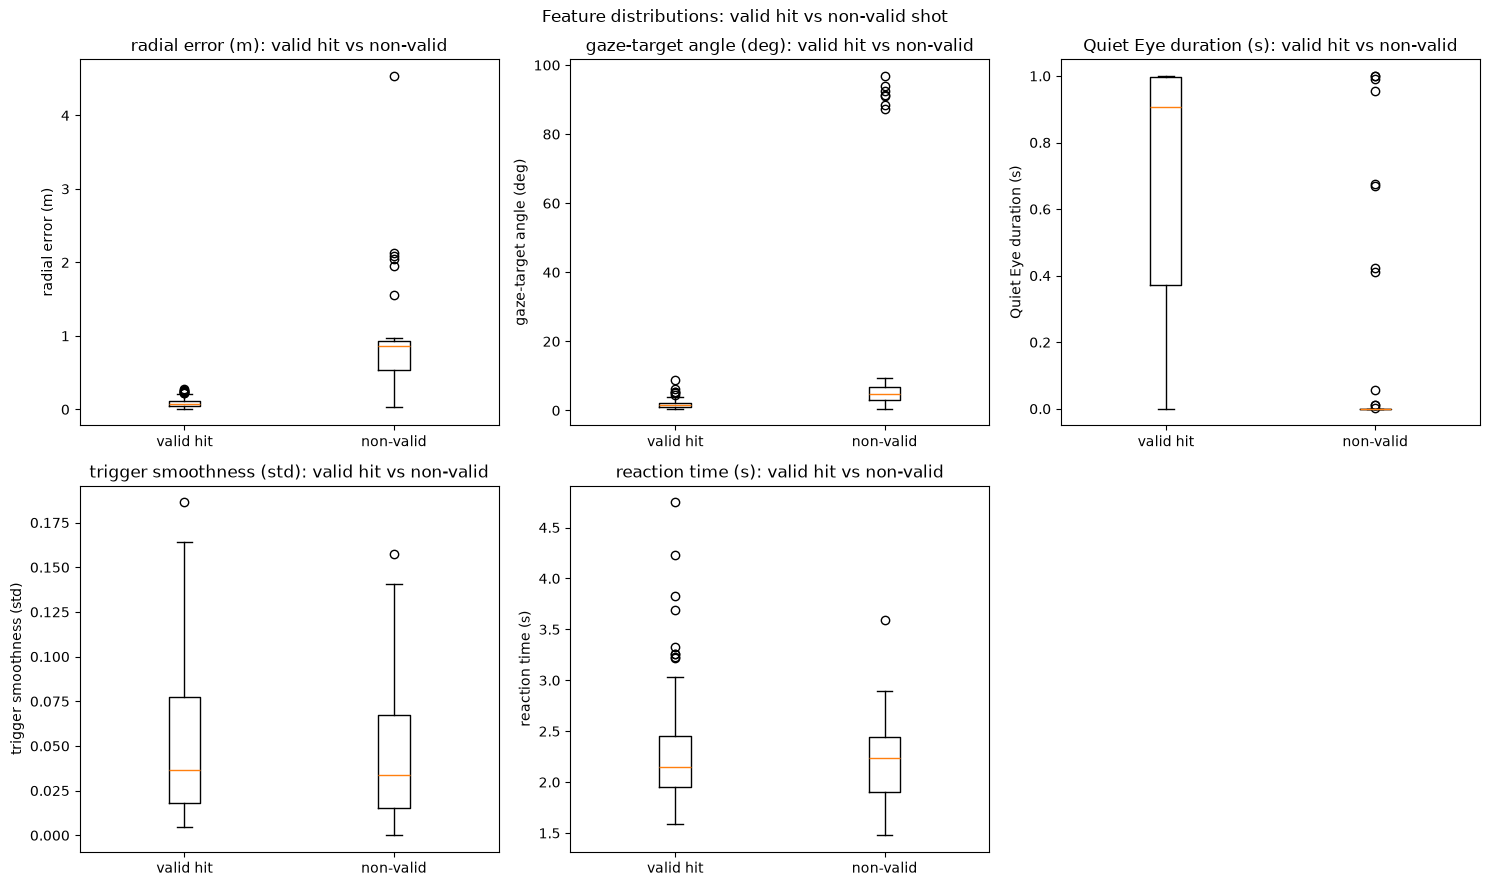

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_good_vs_bad(shots, "radial_error_m", axes[0, 0], "radial error (m)")
plot_good_vs_bad(shots, "gaze_target_angle_deg", axes[0, 1], "gaze-target angle (deg)")
plot_good_vs_bad(shots, "quiet_eye_duration_s", axes[0, 2], "Quiet Eye duration (s)")
plot_good_vs_bad(shots, "trigger_smoothness", axes[1, 0], "trigger smoothness (std)")
plot_good_vs_bad(shots, "reaction_time_s", axes[1, 1], "reaction time (s)")
fig.delaxes(axes[1, 2])
fig.suptitle("Feature distributions: valid hit vs non-valid shot")
fig.tight_layout()

Radial error and gaze-target angle both show a clear, large separation
(misses have much larger radial error and much larger gaze-target angle):
strong validation for both. Quiet Eye duration also separates the groups in
the expected direction (valid hits have a longer final on-target fixation),
though with more overlap than the angle feature, consistent with it
capturing a related but distinct, noisier signal (a single critical instant
versus an averaged window). Trigger smoothness and reaction time show weaker
or no separation by hit/miss, which is expected: a shooter can have a clean,
smooth, fast trigger pull and still miss for purely aim-related reasons.
These two are technique measures, not outcome measures, and get validated
differently below (against each other and against between-user variation,
not against the binary hit/miss label).

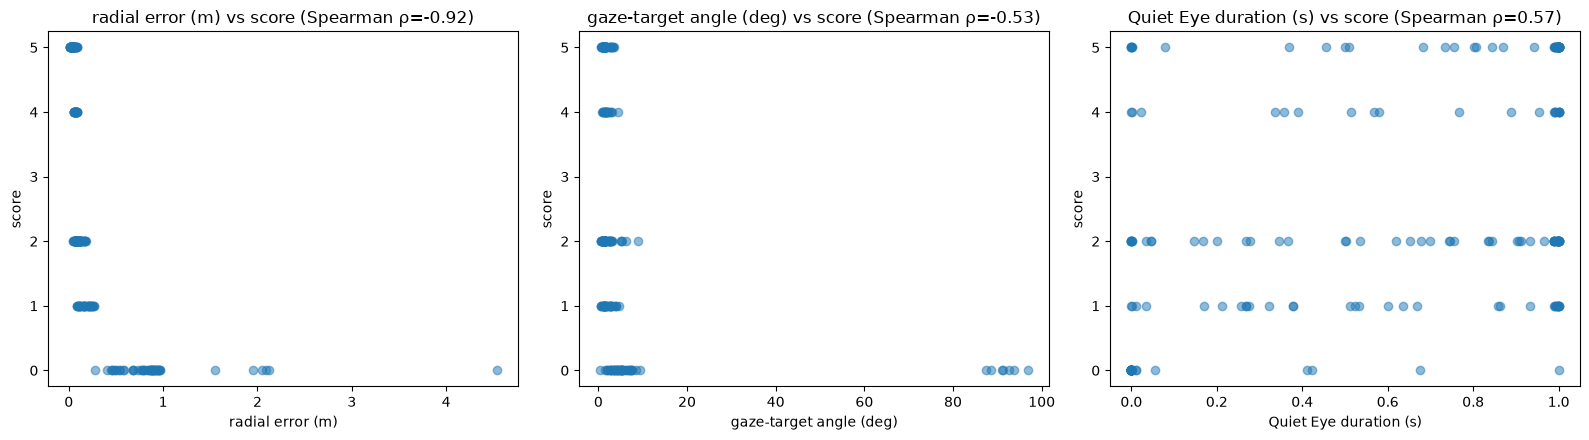

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_feature_vs_score(shots, "radial_error_m", axes[0], "radial error (m)")
plot_feature_vs_score(shots, "gaze_target_angle_deg", axes[1], "gaze-target angle (deg)")
plot_feature_vs_score(shots, "quiet_eye_duration_s", axes[2], "Quiet Eye duration (s)")
fig.tight_layout()

All three correlate with the engine's own `score` field in the expected
direction (more error or a wider gaze miss means a lower score; a longer
Quiet Eye means a higher score), without us ever telling the pipeline what
`score` was. That's independent validation that these features track real
shot quality rather than an artifact of how they were built.

One limitation of `score`: it only takes 5 distinct values across 216 shots,
so it's a coarse yardstick. As a check, we re-ran the same correlations using
`shot_quality_pct` (Section 2's continuous 0-100 rescaling of
`radial_error_m`) as the outcome instead, for the three features that aren't
themselves a transform of radial error.

In [14]:
for col in ["gaze_target_angle_deg", "quiet_eye_duration_s", "trigger_smoothness"]:
    rho_score = shots[[col, "score"]].corr(method="spearman").iloc[0, 1]
    rho_quality = shots[[col, "shot_quality_pct"]].corr(method="spearman").iloc[0, 1]
    print(f"{col:25s} vs score: {rho_score:+.2f}   vs shot_quality_pct: {rho_quality:+.2f}")

gaze_target_angle_deg     vs score: -0.53   vs shot_quality_pct: -0.55
quiet_eye_duration_s      vs score: +0.57   vs shot_quality_pct: +0.57
trigger_smoothness        vs score: -0.07   vs shot_quality_pct: -0.05


The two outcomes agree closely (within 0.02 of each other on every feature):
gaze angle and Quiet Eye both track shot quality at a moderate ρ≈0.5-0.6,
trigger smoothness barely at all (ρ≈-0.05 to -0.07). So the picture from
Section 3's "engine score" check isn't a quantization artifact of having
only 5 score levels - a continuous, higher-resolution outcome tells the same
story.

In [15]:
# Redundancy check: are the domains actually telling us different things, or
# are they all just proxies for the same underlying "good session" effect?
# Covers both the main features and the two supplementary ones, so we can
# see whether the metrics we set aside are at least adding distinct
# information, even though they didn't clear the bar above to be promoted.
feature_cols = MAIN_FEATURES + SUPPLEMENTARY_FEATURES
shots[feature_cols].corr(method="spearman").round(2)

,reaction_time_s,radial_error_m,trigger_smoothness,gaze_target_angle_deg,quiet_eye_duration_s,trigger_press_duration_s,pupil_diameter_mm
reaction_time_s,1.00,-0.11,-0.01,0.00,0.01,0.34,0.23
radial_error_m,-0.11,1.00,0.05,0.55,-0.57,-0.17,-0.05
trigger_smoothness,-0.01,0.05,1.00,-0.05,-0.12,-0.09,-0.23
gaze_target_angle_deg,0.00,0.55,-0.05,1.00,-0.84,-0.24,0.01
quiet_eye_duration_s,0.01,-0.57,-0.12,-0.84,1.00,0.31,0.08
trigger_press_duration_s,0.34,-0.17,-0.09,-0.24,0.31,1.00,0.39
pupil_diameter_mm,0.23,-0.05,-0.23,0.01,0.08,0.39,1.00


Most correlations are modest (|ρ| mostly under 0.3), which suggests each
feature is contributing something distinct rather than all of them
re-measuring "had a good day." That's what the brief is after - different
performance domains, not several views of the same underlying thing - and
it holds for the two supplementary features too, not just the main five.

The one clear exception is `quiet_eye_duration_s` vs `gaze_target_angle_deg`
(ρ ≈ -0.84 per shot). Both measure gaze-target alignment from overlapping
data, so a strong per-shot relationship isn't surprising. What actually
matters is whether they *rank shooters* the same way - that's checked
directly below.

In [16]:
# Same question, but at the level a coach actually cares about: does ranking
# shooters by focus agree with ranking them by Quiet Eye?
rank_corr = scores[["focus", "quiet_eye"]].corr(method="spearman").iloc[0, 1]
print(f"per-user skill-score rank correlation (focus vs quiet_eye): {rank_corr:.2f}")
scores[["focus", "quiet_eye"]].round(0)

per-user skill-score rank correlation (focus vs quiet_eye): 0.54


,focus,quiet_eye
user_id,,
234,71.0,86.0
235,86.0,100.0
237,57.0,43.0
238,29.0,57.0
240,0.0,71.0
243,14.0,14.0
244,43.0,29.0


At ρ ≈ 0.5, the per-user rankings agree only moderately, well below the
per-shot correlation. User 240 is the clearest case: worst in the cohort on
average gaze-target angle, but mid-pack on Quiet Eye duration. That's a
shooter whose gaze wanders during the approach but snaps onto target right
at the moment of the shot. A coaching report built on `gaze_target_angle_deg`
alone would flag this person as "not looking at the target," but Quiet Eye
duration tells a more precise story: eyes are on target when it counts,
just not before that. That's the complementary information that justifies
keeping both as main features instead of picking one.

In [17]:
# Case study: best and worst single shots by radial error, to see the features
# explaining concrete behavior rather than just summary statistics.
best = shots.loc[shots["radial_error_m"].idxmin()]
worst = shots.loc[shots["radial_error_m"].idxmax()]
pd.DataFrame([best, worst], index=["best shot", "worst shot"])[
    ["user_id", "object_id", "score", "radial_error_m", "reaction_time_s",
     "trigger_smoothness", "gaze_target_angle_deg", "valid_hit_recomputed"]]

,user_id,object_id,score,radial_error_m,reaction_time_s,trigger_smoothness,gaze_target_angle_deg,valid_hit_recomputed
best shot,235,LINE_1/5/HEAD/A,5.0,0.007830,3.023,0.013328,0.962530,True
worst shot,237,WallBack_Collider,0.0,4.536881,2.240,0.069883,93.859364,False


The worst shot by radial error also has a far larger gaze-target angle than
the best one. That's a single concrete case of the gaze feature explaining a
miss that the precision number alone can't diagnose: was this a motor
problem, or did the shooter just look at the wrong place?

### Split time: fixing the `reaction_time_s` confound (bullet 2+)

Section 2 flagged that `reaction_time_s` for the second-and-later bullet in
a multi-bullet repetition is buzzer-to-shot, so it silently carries
whatever time was already spent on bullet 1. `split_time_s` times each
bullet from the *previous* shot instead - the standard practical-shooting
follow-up-speed metric, and well-defined for every bullet after the first.

In [18]:
st = split_times(shots)
multi = st[st["bullet_idx_in_rep"] > 0]
print(f"{len(multi)} bullet-2+ shots across the cohort")
print(f"reaction_time_s: mean {multi['reaction_time_s'].mean():.2f}s (range {multi['reaction_time_s'].min():.2f}-{multi['reaction_time_s'].max():.2f}s)")
print(f"split_time_s:    mean {multi['split_time_s'].mean():.2f}s (range {multi['split_time_s'].min():.2f}-{multi['split_time_s'].max():.2f}s)")

49 bullet-2+ shots across the cohort
reaction_time_s: mean 2.44s (range 1.81-4.75s)
split_time_s:    mean 0.44s (range 0.17-2.83s)


For these shots, `reaction_time_s` runs far higher than `split_time_s` -
purely the confound (carrying bullet 1's time), not a slower reflex on
later bullets. **`split_time_s` is the number to report for follow-up-shot
speed; `reaction_time_s` should be read as "first-bullet reaction time"
only.**

### Directional drift: bias vs. spread within `radial_error_m`

`radial_error_m` collapses each miss into a single magnitude, so a shooter
who's consistently high by 30cm and one who scatters 30cm in random
directions get the same number. Splitting the signed offset into a **mean
bias vector** (fixable with a sight/grip/stance adjustment) and **spread**
(a consistency problem, fixable only by practice) tells two different
coaching stories from the same shots.

In [19]:
drift = drift_summary(shots)
drift.round(3)

,bias_x_m,bias_y_m,spread_m,bias_mag_m,bias_direction
user_id,,,,,
234,0.022,0.158,0.268,0.159,up
235,-0.007,0.142,0.266,0.142,up
237,-0.135,0.271,0.819,0.303,upper-left
238,0.014,0.318,0.441,0.319,up
240,-0.019,0.347,0.590,0.347,up
243,-0.012,0.297,0.349,0.297,up
244,0.010,0.160,0.402,0.160,up


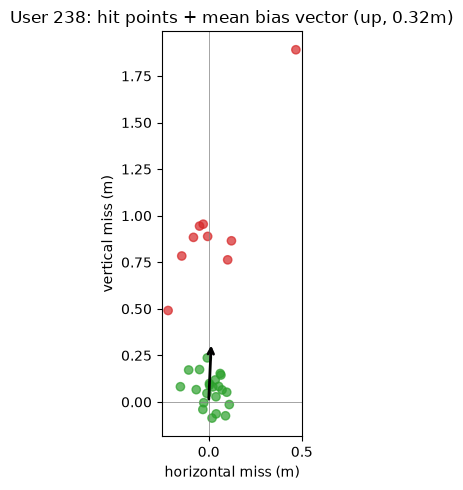

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_hit_map(shots, DEMO_USER, ax)
b = drift.loc[DEMO_USER]
ax.annotate("", xy=(b["bias_x_m"], b["bias_y_m"]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="black", linewidth=2))
ax.set_title(f"User {DEMO_USER}: hit points + mean bias vector ({b['bias_direction']}, {b['bias_mag_m']:.2f}m)")
fig.tight_layout()

Every shooter in this cohort is biased **up** (`bias_y_m` positive for all
7) by roughly 14-35cm - plausibly a sight-model artifact
(`session_metadata`'s `gun.sights.front_offset.y`/`back_offset.y` are both
positive, ~0.08m) rather than a per-shooter quirk, since it's consistent
across the whole cohort. User 237 stands out: a large bias (30cm, drifting
upper-left) *and* the largest spread (82cm) in the cohort - their
`radial_error_m` average alone would just look mediocre, but the breakdown
shows two separate problems (aim *and* consistency), not one. The demo user
above (238) has a similarly large bias (32cm, straight up) but a more
moderate spread (44cm) - mostly a sight/stance fix, less so a consistency
problem.

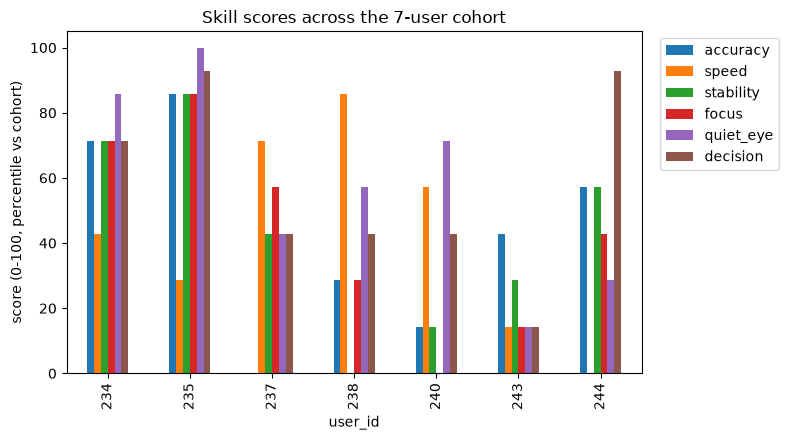

In [21]:
# Cross-user norms: cohort-wide view of the 0-100 percentile scores.
fig, ax = plt.subplots(figsize=(8, 4.5))
scores.plot.bar(ax=ax)
ax.set_ylabel("score (0-100, percentile vs cohort)")
ax.set_title("Skill scores across the 7-user cohort")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

Every feature so far has been validated *across* shooters in the 7-user cohort. Each cohort session also has enough shots (about 31) to ask a *within*-session question too: does this shooter's performance drift between the first and last third of their own session? `session_trend` (`shooter/reporting.py`) answers exactly that, per user and per feature domain, after subtracting each shot's target-row mean so a late run of harder (row-2) targets doesn't masquerade as fatigue.

In [22]:
from shooter.reporting import session_trend

trend = session_trend(shots).set_index("user_id")
trend[[c for c in trend.columns if c.endswith("_trend")]].round(3)

,reaction_time_s_trend,radial_error_m_trend,trigger_smoothness_trend,gaze_target_angle_deg_trend,quiet_eye_duration_s_trend
user_id,,,,,
234,-0.074,0.008,-0.003,0.085,0.001
235,0.034,0.006,-0.002,-0.138,0.014
237,0.097,0.004,-0.006,-0.026,-0.056
238,-0.104,0.055,-0.010,0.619,-0.152
240,0.083,-0.002,-0.011,0.135,-0.051
243,0.098,-0.064,-0.015,-0.975,0.010
244,-0.157,0.015,-0.006,-0.193,0.035


Sign convention: for `reaction_time_s`, `radial_error_m`, `trigger_smoothness`, and `gaze_target_angle_deg`, lower is better, so a **negative** trend means the shooter improved across their session; `quiet_eye_duration_s` is the opposite (**positive** = improved).

Most of these trends are small - a single ~6-minute, 31-shot session usually isn't long enough to show a clear drift either way. The two exceptions sit at opposite ends: user 238 (already flagged in Section 1 for low focus and stability) gets *worse* on both eye-behavior features as their session goes on - gaze-target angle widens substantially (+0.62°) and Quiet Eye duration shrinks (-0.15s) - consistent with an existing weakness compounding rather than staying static. User 243 shows the opposite: gaze-target angle improves sharply (-0.98°) across their session. Both are single-user, single-session observations, not a cohort-wide pattern.

What this table can't show is a *repetition-level* learning curve: each repetition in these cohort files is fired once, at a different target, so there's no repeated structure within a single repetition to track. The excluded `WarmUp` file (user 243, scenario `11601`) is the one file in the sample built differently - 72 repetitions across 11 drill types in about 15 minutes, instead of 24 repetitions of a single drill in about 6 minutes - and lets us ask the repetition-level version of this question instead.

In [23]:
from shooter.features import add_all_features

warmup_path = DATA_DIR / "20260601113226_243_2531_11601.event.json"
frames_wu, shots_wu = parse_file(warmup_path)
dominant_eye_wu = frames_wu["session_metadata"]["dominant_eye"].iloc[0]
shots_wu = add_all_features(shots_wu, frames_wu, dominant_eye_wu)
shots_wu["drill_family"] = shots_wu["drill_id"].str.extract(r"WarmUp_([A-Za-z]+)_")

shots_wu.groupby("drill_family").agg(n_reps=("rep_idx", "nunique"), n_shots=("rep_idx", "size"))

,n_reps,n_shots
drill_family,,
FriendVsFoe,10,46
JohnWick,2,30
NeutralizeThreat,5,15
SplitShooting,8,28
SuppressiveFire,4,60
TakeCover,8,16
TargetAcquisition,8,8
TargetIdentification,10,45
TargetTransition,10,60


`TargetAcquisition` is the one drill family here that's literally the same
task as the cross-user cohort's single drill - one bullet, one target,
target row/column varied each time - just repeated 8 times in a row for one
person instead of once each for 7 people. That makes it the cleanest
same-task comparison available in this file.

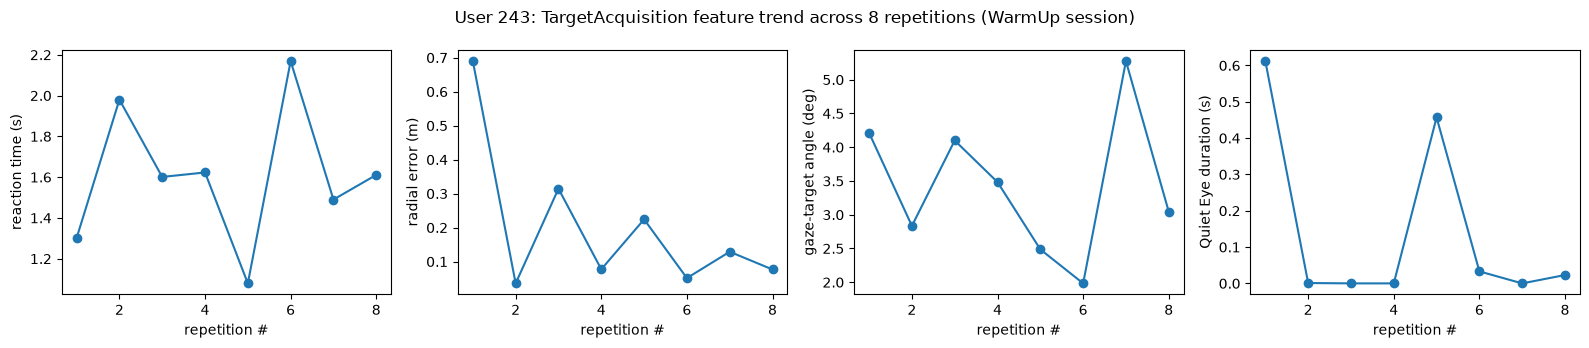

In [24]:
ta = shots_wu[shots_wu["drill_family"] == "TargetAcquisition"].reset_index(drop=True)
ta["rep_order"] = range(1, len(ta) + 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col, label in zip(
    axes,
    ["reaction_time_s", "radial_error_m", "gaze_target_angle_deg", "quiet_eye_duration_s"],
    ["reaction time (s)", "radial error (m)", "gaze-target angle (deg)", "Quiet Eye duration (s)"],
):
    ax.plot(ta["rep_order"], ta[col], marker="o")
    ax.set_xlabel("repetition #")
    ax.set_ylabel(label)
fig.suptitle("User 243: TargetAcquisition feature trend across 8 repetitions (WarmUp session)")
fig.tight_layout()

Across these 8 single-shot repetitions, none of the four features show a
trend worth calling a learning curve or fatigue: rank correlation with
repetition order is weak in every case (|ρ| ≤ 0.33). With only 8
repetitions, that's the expected outcome - this is exactly the "not enough
repeated structure" problem flagged in Section 5, just less severe here than
for the one-rep-per-target cohort files. The honest read is "no detectable
trend at this sample size," not "this shooter is flat across repetitions."

The rest of the session has far more repetitions (72 total), just spread
across 11 different drills rather than one. That's still useful for a
broader question: does this shooter's performance drift over the course of
a longer session, regardless of which drill they're on?

reaction time, first 10 vs last 10 repetitions: 1.51s -> 1.59s
valid-hit rate, first half vs second half of session: 87% -> 91%


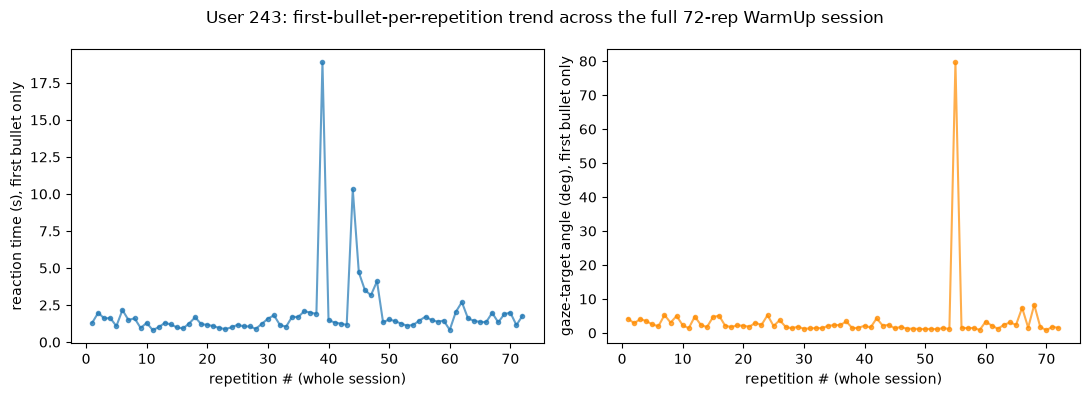

In [25]:
# Multi-bullet repetitions inflate reaction_time_s for later bullets (Section
# 2's caveat: bullet 2's "reaction time" includes bullet 1's). Comparing raw
# reaction_time_s across the whole session naively would mostly be measuring
# "how many bullets were in this rep," not fatigue -- so we isolate the first
# bullet of each repetition, which is on a level footing throughout.
shots_wu_sorted = shots_wu.sort_values("shot_start_time").reset_index(drop=True)
shots_wu_sorted["bullet_idx_in_rep"] = shots_wu_sorted.groupby("rep_idx").cumcount()
first_bullets = shots_wu_sorted[shots_wu_sorted["bullet_idx_in_rep"] == 0].reset_index(drop=True)
first_bullets["rep_order"] = range(1, len(first_bullets) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(first_bullets["rep_order"], first_bullets["reaction_time_s"], marker=".", alpha=0.7)
axes[0].set_xlabel("repetition # (whole session)"); axes[0].set_ylabel("reaction time (s), first bullet only")
axes[1].plot(first_bullets["rep_order"], first_bullets["gaze_target_angle_deg"], marker=".", alpha=0.7, color="darkorange")
axes[1].set_xlabel("repetition # (whole session)"); axes[1].set_ylabel("gaze-target angle (deg), first bullet only")
fig.suptitle("User 243: first-bullet-per-repetition trend across the full 72-rep WarmUp session")
fig.tight_layout()

print(f"reaction time, first 10 vs last 10 repetitions: "
      f"{first_bullets['reaction_time_s'][:10].mean():.2f}s -> {first_bullets['reaction_time_s'][-10:].mean():.2f}s")
print(f"valid-hit rate, first half vs second half of session: "
      f"{shots_wu_sorted['valid_hit_recomputed'][:175].mean():.0%} -> {shots_wu_sorted['valid_hit_recomputed'][175:].mean():.0%}")

Worth pausing on the confound this isolation avoids: averaging
`reaction_time_s` over *all* shots in session order (not just the first
bullet of each rep) makes it look like reaction time collapses from about
1.5s to over 8s across the session - but that's an artifact of later drills
in this `WarmUp` curriculum requiring far more bullets per repetition (up to
15), not the shooter slowing down. Looking only at the first bullet of each
repetition - the one apples-to-apples comparison available across the whole
session - that effect disappears: reaction time is flat (about 1.5s in both
the first and last 10 repetitions), gaze-target angle drifts slightly
*better* as the session goes on (ρ ≈ -0.37 with repetition order), and the
valid-hit rate is, if anything, slightly higher in the second half of the
session (87% -> 91%) than the first.

For this one shooter, across this one 15-minute, 72-repetition session,
there's no sign of fatigue - focus and accuracy hold steady or tick up
rather than decay. That's a real, useful finding on its own (this person can
sustain performance over a longer session), but it rests on **n = 1
shooter, 1 session** - it says nothing about whether that holds for anyone
else, and it's exactly the gap Section 5's "learning-curve features" bullet
points at: this file is the one exception in the sample with enough
repeated structure to even ask the question, not proof the answer
generalizes.

## 5. Features Considered But Not Built

Beyond the two supplementary features in Section 2 (computed, just not
promoted), a couple of other ideas didn't make it into the pipeline at all:

- **Headset/controller path stability before the shot** (hand/head sway).
  The frame data would support this, but conceptually it overlaps heavily
  with `trigger_smoothness`: both are really asking "how steady was the
  shooter right before the shot?" With only seven users, adding a third
  highly-correlated steadiness metric felt more likely to dilute
  interpretability than add signal. Worth revisiting if the cohort grows.
- **Convergence distance** (`eye_data.convergence`). It's in the schema, but
  was flat at 100.0 across the sample we explored, which suggests it isn't
  actively computed in this build or scenario - not reliable enough to build
  a feature on yet.

**Valuable, but needs more data than this sample has:**
- *Real per-user norms.* The 0-100 scores in this report are percentiles
  within a group of 7 people on one scenario - useful for comparing this
  specific cohort, but not a stable population baseline. Turning "70th
  percentile" into something that means the same thing for a new user next
  month would need norms built from dozens to hundreds of sessions per skill
  level.
- *Learning-curve features across sessions.* Section 4 shows that a
  within-session version of this question is answerable when a session has
  enough repetitions (the `WarmUp` file's 72), but that's one user, one
  session. Telling apart "this person is learning" from "this person just
  has a good day" needs multiple sessions per user over time, which this
  sample doesn't have (243 has two sessions, but on different scenarios, so
  even that pair isn't a clean before/after comparison).
- *Recoil/follow-through and stance/posture features* would need sensor
  logs this schema doesn't have (full-body tracking, weapon recoil
  telemetry).
- *Audio* (verbal commands, ambient distraction) isn't referenced anywhere
  in the schema and would need an entirely new log type.

**Logging changes that would help:** an explicit `shot_break_time` captured
directly off the trigger sensor (instead of inferring it from the
`trigger_pull_value` curve) would make the trigger-control features exact
rather than approximated. A per-frame `gaze_confidence` score, instead of
the binary `valid`/`open` flags, would also remove the need to infer the
eye-tracking fallback in Section 0 from raw validity rates.

In [26]:
print(f"reaction time range across cohort: {raw['speed'].min():.1f}s - {raw['speed'].max():.1f}s")
print(f"gaze-target angle range across cohort: {raw['focus'].min():.1f}deg - {raw['focus'].max():.1f}deg "
      f"({raw['focus'].max() / raw['focus'].min():.1f}x spread)")
print(f"Quiet Eye duration range across cohort: {raw['quiet_eye'].min():.2f}s - {raw['quiet_eye'].max():.2f}s "
      f"({raw['quiet_eye'].max() / max(raw['quiet_eye'].min(), 0.01):.0f}x spread)")

reaction time range across cohort: 2.0s - 2.5s
gaze-target angle range across cohort: 1.6deg - 10.0deg (6.1x spread)
Quiet Eye duration range across cohort: 0.06s - 0.86s (14x spread)


## 6. Product Manager Summary

**Scope:** five features, one per domain (timing, motor control, trigger
control, eye behavior, cognitive), plus a derived decision-quality metric.
Two more metrics were built and validated alongside these but set aside as
supplementary - see Section 2 for the reasoning on each.

**What we learned about this cohort:** reaction time is fairly uniform
across the 7 shooters (roughly 2.0-2.5s); everyone engages at about the same
speed once the buzzer goes. The real spread is in eye behavior. Gaze-target
angle varies by roughly 6x between the most and least target-focused
shooter, and Quiet Eye duration spreads even wider (see the numbers above).
Eye behavior is the single most differentiating skill in this cohort, and
it's also the domain that's easiest to turn into a real-time in-VR coaching
cue: "look at the target," "hold your sight picture before you fire."

**Within a single session** (Section 4), most of the cohort is flat from
the first to the last third of their ~31-shot session - one session isn't
long enough to show a clear trend either way for most people. But it isn't
flat for everyone: user 238 (this report's low-focus example) gets
measurably worse on both eye-behavior features as their session goes on,
while user 243 improves on the same metric over their session. That's the
kind of individual signal a real-time in-session dashboard could flag as it
happens, rather than only after the fact. Separately, the longer 72-repetition
`WarmUp` session (one shooter, one session) shows no sign of fatigue at the
repetition level - reaction time, gaze-target angle, and valid-hit rate all
hold steady or improve slightly from the first half to the second. Both
observations are single-person, single-session; turning either into a real
"fatigue/learning" product feature needs the same metrics tracked across
many sessions per user, not just many shots or repetitions in one.

**Strong and weak skills:** decision quality (shooting the right target) and
eye behavior (focus and Quiet Eye) separate the cohort the most; reaction
time separates it the least, with trigger control and accuracy in between.
Focus and Quiet Eye only agree moderately on how they rank shooters (ρ ≈ 0.5,
Section 3), so it's worth surfacing both rather than treating one as "the"
eye metric - each catches a shooter the other would miss. One user, for
example, ranks worst on average gaze alignment but mid-pack on Quiet Eye:
eyes wander during the approach, but lock on right when it counts.

**Most reliable features:** `radial_error_m` and `gaze_target_angle_deg` are
the two we'd trust most. Both show a large, sensible gap between valid hits
and misses (Section 3), and both correlate with the engine's own shot score
without ever having been told what that score was. `quiet_eye_duration_s`
shows the same pattern, just more weakly, since it's a single-instant
measure and noisier per shot - but it adds a distinct, literature-backed
angle the others don't cover. `trigger_smoothness` and `reaction_time_s` are
technique measures rather than outcome measures, so they validate
differently (by between-user spread, not hit/miss separation): trust them as
*process* feedback, not as a stand-in for "did they hit."

**What would improve logging or product feedback:** capture an explicit
trigger-break event instead of inferring it from the raw pull curve; log
per-frame eye-tracking confidence instead of a binary valid/open flag, so
gaze features don't need an inferred per-user eye fallback; and collect
multiple sessions per user before showing anyone a percentile score, so
"better than 70% of users" reflects a real population rather than these
7 people.

**Two findings worth acting on directly:** every shooter in this cohort
shoots consistently *high* (Section 3's bias/spread breakdown of
`radial_error_m`), which looks like a sight-model artifact rather than a
skill gap shared by seven unrelated people - worth checking against the
simulated gun/sight geometry before it's coached as an aim problem. And for
any follow-up-shot speed claim, `split_time_s` is the number to use, not
raw `reaction_time_s` - the latter overstates bullet-2+ time by carrying
bullet 1's reaction time along with it.